In [1]:
from src.dataloading import DeepDataLoader, EpiDataLoader
from src.utils import get_data_env

modelname       = 'gatv2model'
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1


# training hparams
n_epochs        = 5
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :   {'mode': 'min', 'factor': 0.5, 'patience': 7},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

model_hparams = {
    'hidden_size' : 256,
    'num_layers' : 2,           # spatial
    'temporal_layers' : 2,      # time
    'num_heads' : 3
}

epiloader = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epiloader.add_time_features()
epiloader.log_transform_target()
epiloader.set_splits(split_trainval, split_valtest)
epiloader.normalize()
epiloader.add_lagged_features(lags = lags)
epiloader.finalize()

epidata_loader_basis = DeepDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))

==     Training gatv2 id graph     ==
Epoch 1 train loss: 0.7085, val loss: 1.2383 ✓ (new best)
Epoch 2 train loss: 0.6523, val loss: 1.1229 ✓ (new best)
Epoch 3 train loss: 0.6299, val loss: 0.9707 ✓ (new best)
Epoch 4 train loss: 0.6174, val loss: 0.9142 ✓ (new best)


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 506.39it/s]


Test loss: 1.3492
Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))

==     Training gatv2 bn graph     ==
Epoch 1 train loss: 0.7451, val loss: 1.2704 ✓ (new best)
Epoch 2 train loss: 0.6710, val loss: 1.1166 ✓ (new best)
Epoch 3 train loss: 0.6602, val loss: 0.8355 ✓ (new best)
Epoch 4 train loss: 0.6405, val loss: 0.8092 ✓ (new best)


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 551.41it/s]

...

Test loss: 1.2617


Dataloader Snapshot: GraphDataLoaderEntry(x=(400, 3, 1), y=(400, 1), edge_index=(2, 1754), edge_weight=(1754,))

==     Training gatv2 cm2 graph     ==
Epoch 1 train loss: 0.7974, val loss: 1.3353 ✓ (new best)
Epoch 2 train loss: 0.6750, val loss: 1.2849 ✓ (new best)
Epoch 3 train loss: 0.6637, val loss: 1.0062 ✓ (new best)
Epoch 4 train loss: 0.6345, val loss: 0.9263 ✓ (new best)


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 551.73it/s]

Test loss: 1.3393


PersistenceModel(name='persistence baseline')

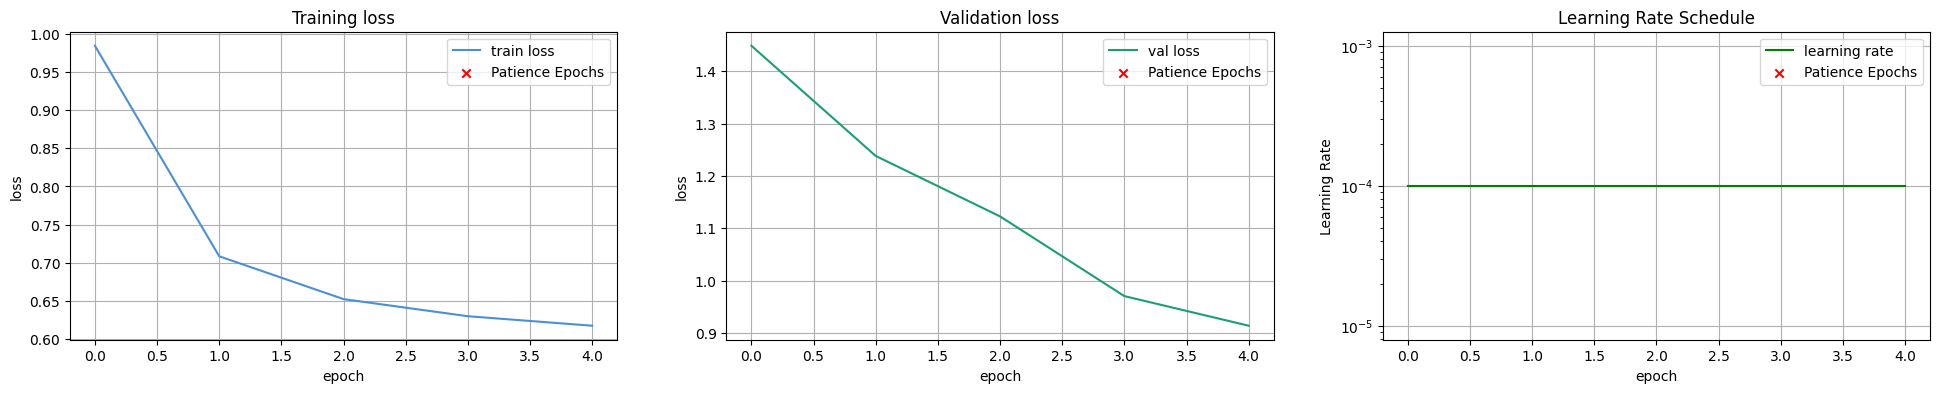

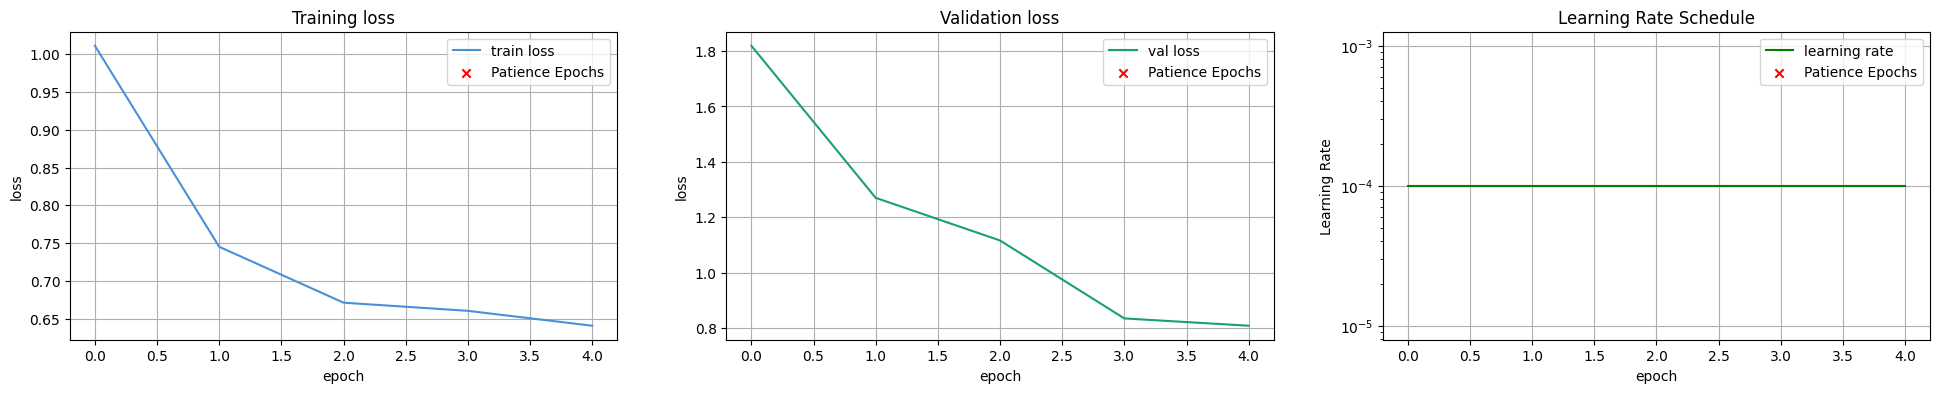

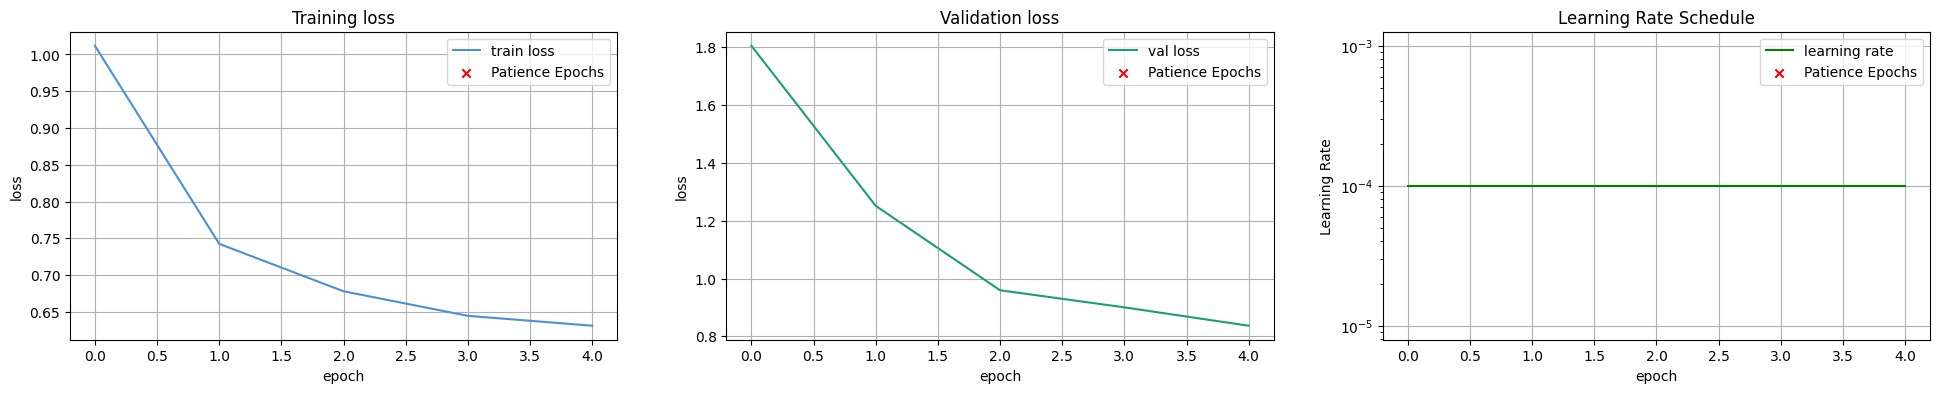

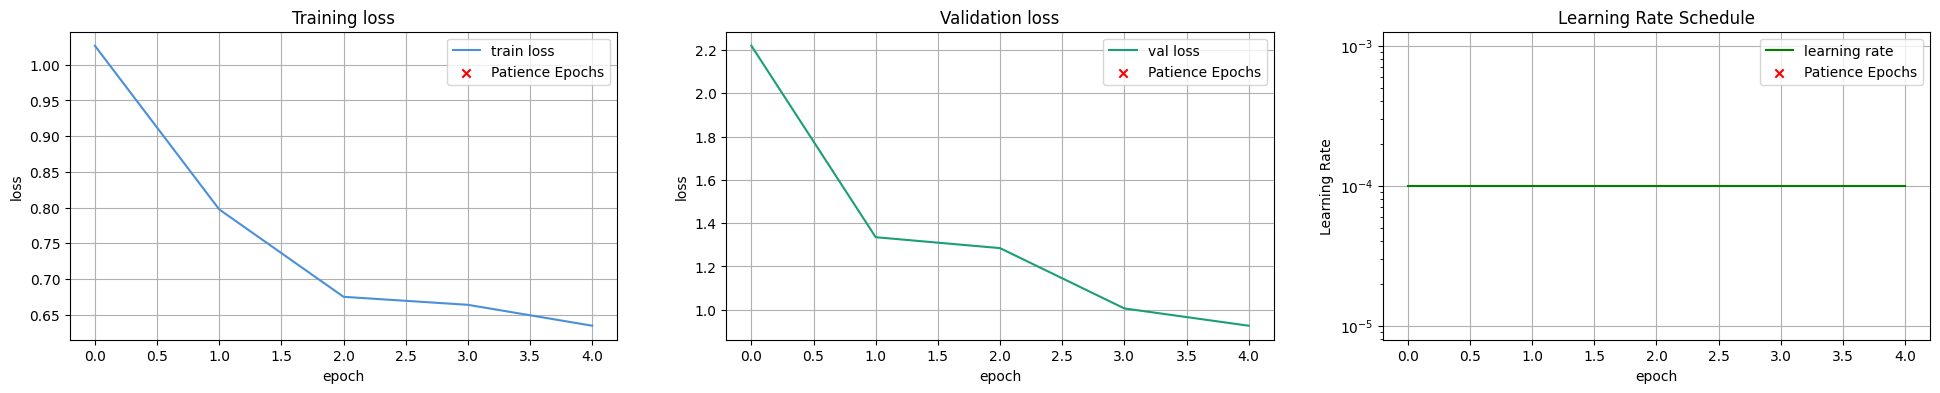

In [2]:
from src.models.deep.gatv2 import GATv2Model
from src.models.base.persistencemodel import PersistenceModel

dl_id  = epidata_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()
dl_bn  = epidata_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()
dl_cm1 = epidata_loader_basis.copy().retrieve_graph('commuter_t2000_selfmean_symmetric').construct_dataloaders()
dl_cm2 = epidata_loader_basis.copy().retrieve_graph('commuter_t2000_selfmean_rowwise').construct_dataloaders()

gatv2_id = GATv2Model(dataloader= dl_id, name = 'gatv2 id graph')
gatv2_id.set_model_hparams(**model_hparams)
gatv2_id.set_global_hparams(**global_hparams)
gatv2_id.train(2)
gatv2_id.forecast('test')

gatv2_bn = GATv2Model(dataloader= dl_bn, name = 'gatv2 bn graph')
gatv2_bn.set_model_hparams(**model_hparams)
gatv2_bn.set_global_hparams(**global_hparams)
gatv2_bn.train(2)
gatv2_bn.forecast('test')

gatv2_cm1 = GATv2Model(dataloader= dl_cm1, name = 'gatv2 cm1 graph')
gatv2_cm1.set_model_hparams(**model_hparams)
gatv2_cm1.set_global_hparams(**global_hparams)
gatv2_cm1.train(2)
gatv2_cm1.forecast('test')

gatv2_cm2 = GATv2Model(dataloader= dl_cm2, name = 'gatv2 cm2 graph')
gatv2_cm2.set_model_hparams(**model_hparams)
gatv2_cm2.set_global_hparams(**global_hparams)
gatv2_cm2.train(2)
gatv2_cm2.forecast('test')

baseline = PersistenceModel(epiloader, name = 'persistence baseline')
baseline.forecast('test')

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National incidence rate (per 10000)'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 223'}, ylabel='incidence'>],
       dtype=object))

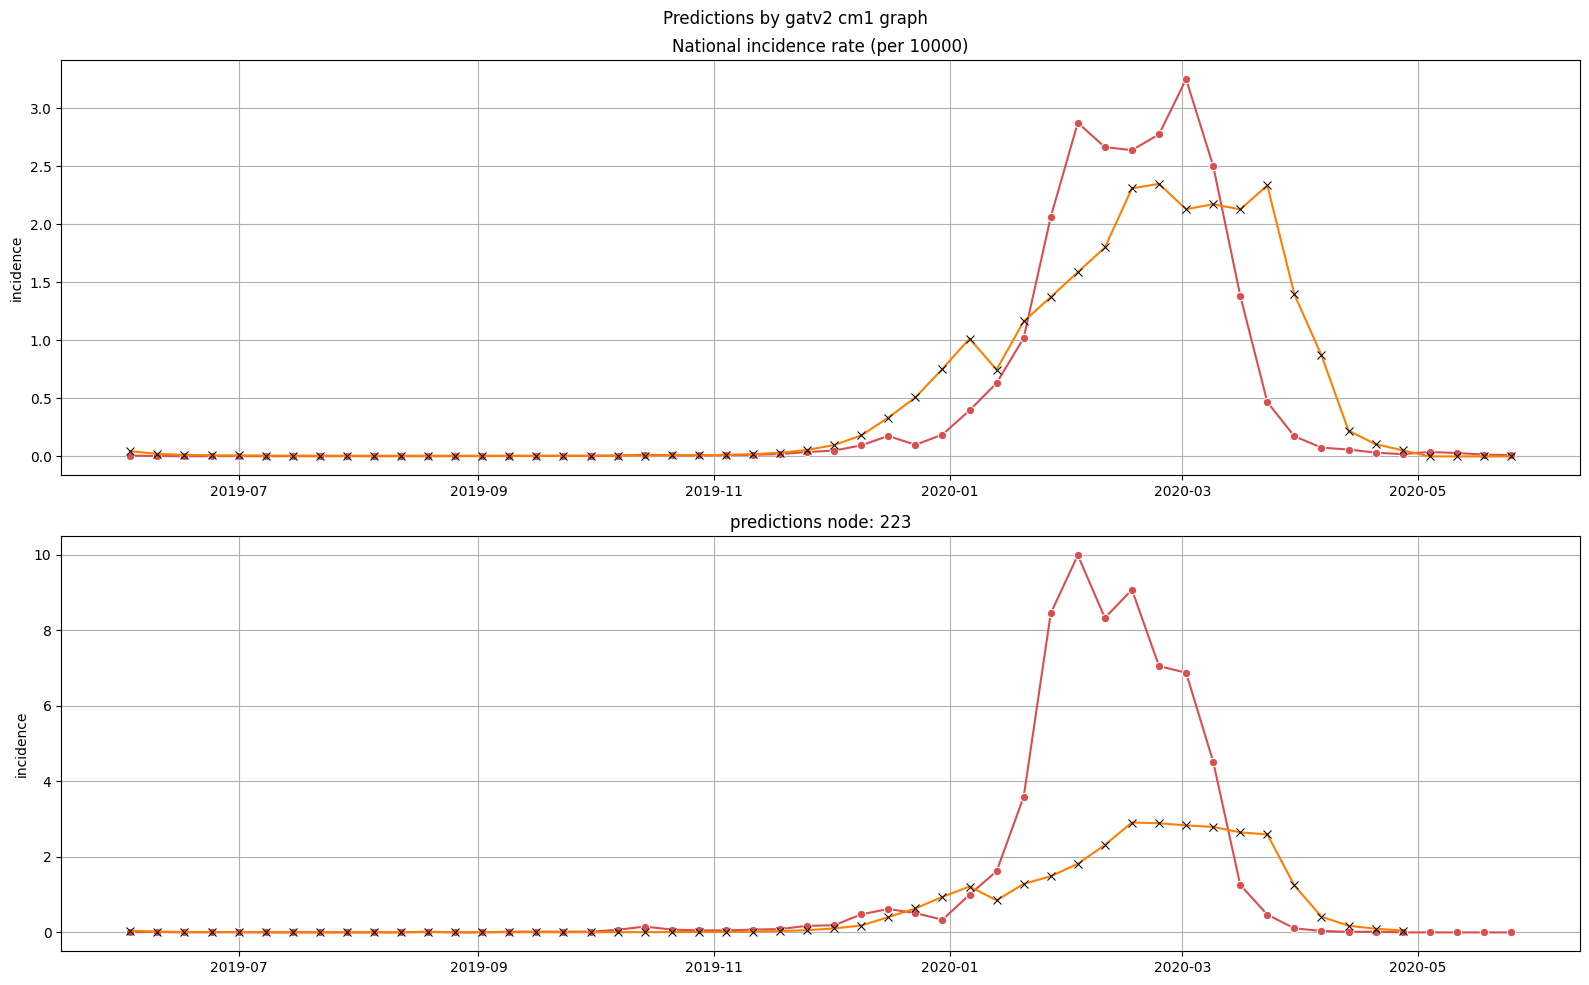

In [3]:
# gatv2_cm1.forecast('train')
gatv2_cm1.show_forecasts('test', 223)

2020-03-09 00:00:00


/home/de-schrijvers/projects/germany_gnn/src/models/base/basemodel.py:234: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


(<Figure size 1200x900 with 3 Axes>, array([<Axes: >, <Axes: >], dtype=object))

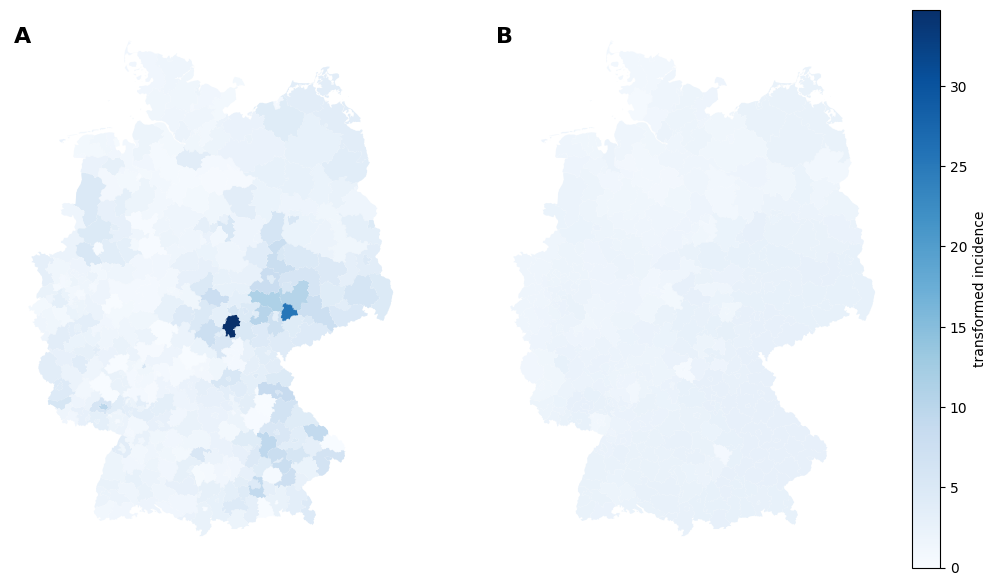

In [4]:
gatv2_cm1.show_forecasts_maps('test',40,'equal')

In [5]:
gatv2_cm1.evaluation_datasets['test']['nontransformed']['horizon_0']

,timestamp,node,timestamp_sin,timestamp_cos,incidence_lag3,train,val,test,incidence,pred
0,2019-06-03,0,0.354605,-0.935016,0.000000,False,False,True,0.000000,0.044494
1,2019-06-03,1,0.354605,-0.935016,0.162078,False,False,True,0.000000,0.044701
2,2019-06-03,2,0.354605,-0.935016,0.000000,False,False,True,0.000000,0.044573
3,2019-06-03,3,0.354605,-0.935016,0.000000,False,False,True,0.000000,0.044691
4,2019-06-03,4,0.354605,-0.935016,0.075079,False,False,True,0.000000,0.044863
...,...,...,...,...,...,...,...,...,...,...
20795,2020-05-25,395,0.508531,-0.861044,0.000000,False,False,True,0.000000,NaN
20796,2020-05-25,396,0.508531,-0.861044,0.000000,False,False,True,0.000000,NaN
20797,2020-05-25,397,0.508531,-0.861044,0.000000,False,False,True,0.000000,NaN
20798,2020-05-25,398,0.508531,-0.861044,0.000000,False,False,True,0.206894,NaN
